# Análise Profunda de Atrasos - Logística

Esta análise foca em identificar padrões de atraso, especificamente validando a janela de risco das 17h-18h, e explorando outras variáveis para o futuro modelo preditivo.

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurações de plotagem
plt.style.use('ggplot')
sns.set_palette("viridis")
%matplotlib inline

### Carregamento dos dados

In [65]:
# Força limpeza
import importlib
import data_preparation_final
importlib.reload(data_preparation_final)

# Importar lógica de preparação de dados existente
from data_preparation_final import load_and_clean_data

# Este comando já extrai e devolve o dataset limpo com as variáveis temporais criadas.
df = load_and_clean_data('pedidos_logistica.parquet')

# Opcional (apenas para verificar formato para as próximas análises)
# df.head()
print(f"Dados carregados: {df.shape}")

Carregando dados de pedidos_logistica.parquet...
Removendo colunas desnecessárias: ['id', 'cidade_destinatario']
Colunas após renomeação:
cod_pedido, uf, grp_transportadora
dt_despacho_pedido, dt_entrega_pedido, dt_previsao_entrega_cliente
dt_criacao, dt_pagamento_pedido, flg_existem_ocorrencias
tp_praca, des_unidade_negocio, des_cd_origem
qtd_dias_tat, tp_performance_entrega, cidade_destinatario
Removendo registros inconsistentes (entrega antecede despacho): 7
Realizando engenharia de features...
Processamento concluído. Formato final: (490210, 20)
Salvando dataset limpo em pedidos_logistica_limpo.parquet...
Dados carregados: (490210, 20)


### Featuring Engineering

In [185]:
import numpy as np

# --- 1. Temporal features from dispatch date ---
df['dia_semana_despacho'] = df['dt_despacho_pedido'].dt.dayofweek
df['mes_despacho']        = df['dt_despacho_pedido'].dt.month
df['hora_despacho'] = df['dt_despacho_pedido'].dt.hour
# float32 handles NaT-derived NaN natively (unlike int32)
df['semana_ano']          = df['dt_despacho_pedido'].dt.isocalendar().week.astype('float32')

# Indicador de despacho de fim de semana (sáb=5, dom=6): as redes das operadoras 
# são mais sobrecarregadas nos fins de semana.
df['is_fds_despacho']   = (df['dia_semana_despacho'] >= 5).astype('int8')

# Período de maior procura: novembro (Black Friday) e dezembro (Natal).
df['is_alta_temporada'] = df['mes_despacho'].isin([11, 12]).astype('int8')

# Turno de despacho — despachos mais cedo tendem a ter melhor processamento no mesmo dia
if 'hora_despacho' in df.columns:
    df['turno_despacho'] = pd.cut(
        df['hora_despacho'],
        bins=[-1, 5, 11, 17, 23],
        labels=['Madrugada', 'Manha', 'Tarde', 'Noite']
    ).astype('category')

# --- 2. Derived date-ratio features ---
df['dias_criacao_pagamento'] = (df['dt_pagamento_pedido'] - df['dt_criacao']).dt.days

# Dias que a transportadora tem desde o despacho até a entrega prevista.
df['prazo_apos_despacho'] = (
    df['dt_previsao_entrega_cliente'] - df['dt_despacho_pedido']
).dt.days

# Fração do prazo total já consumida dentro do CD (>1 = prazo já excedido)
df['ratio_cd_prazo'] = (
    df['dias_gastos_cd'] / df['dias_restantes_prazo'].replace(0, np.nan)
).clip(0, 2)

# Margem de entrega líquida: negativa = prazo não cumprido antes do envio
df['margem_entrega'] = df['prazo_apos_despacho'] - df['dias_gastos_cd']

# Variáveis alvo de atraso
df['is_atrasado'] = (df['dt_entrega_pedido'] > df['dt_previsao_entrega_cliente']).astype(int)
if 'tp_performance_entrega' in df.columns:
    # Definindo atraso (usando a coluna de performance oficial do projeto)
    df['is_atrasado_oficial'] = (df['tp_performance_entrega'] == 0).astype(int)

# --- Summary ---
new_cols = [
    'dia_semana_despacho', 'mes_despacho', 'semana_ano',
    'is_fds_despacho', 'is_alta_temporada',
    'dias_criacao_pagamento', 'prazo_apos_despacho',
    'ratio_cd_prazo', 'margem_entrega',
    'is_atrasado', 'is_atrasado_oficial'
]
if 'hora_despacho' in df.columns:
    new_cols = ['hora_despacho', 'turno_despacho'] + new_cols

print(f'Novas features adicionadas ({len(new_cols)}):')
print(df[new_cols].describe(include='number').T[['count', 'mean', 'min', 'max']].to_string())
print("\n")
print(df.describe(include=['category']))

Novas features adicionadas (13):
                           count       mean         min       max
hora_despacho           490210.0  11.372334    0.000000  23.00000
dia_semana_despacho     490210.0   2.376794    0.000000   6.00000
mes_despacho            490210.0   9.717780    1.000000  12.00000
semana_ano              490210.0  40.522694    1.000000  52.00000
is_fds_despacho         490210.0   0.134328    0.000000   1.00000
is_alta_temporada       490210.0   0.464423    0.000000   1.00000
dias_criacao_pagamento  458687.0  -0.078879 -327.000000  15.00000
prazo_apos_despacho     490210.0   6.537200  -64.000000  73.00000
ratio_cd_prazo          458671.0   0.296189    0.000000   2.00000
margem_entrega          458687.0   4.235719 -327.003241  71.44875
is_atrasado             490210.0   0.120295    0.000000   1.00000
is_atrasado_oficial     490210.0   0.036984    0.000000   1.00000


            uf grp_transportadora  tp_praca des_unidade_negocio  \
count   490210             490210    490

### Testes

In [293]:
# Porcentagem de pedidos atrasados com o total
pct_atraso_total = df['is_atrasado'].mean() * 100
# ou
# pct_atraso_total = (len(df[df['is_atrasado'] == 1]) / len(df)) * 100
print(f"Porcentagem de pedidos atrasados (Total): {pct_atraso_total:.2f}%")

# Visualização simples
# plt.figure(figsize=(6, 4))
# sns.countplot(x='is_atrasado', data=df, palette='viridis')
# plt.title('Distribuição de Atrasos (0=No Prazo, 1=Atrasado)')
# plt.show()

# Número de dias de atraso médio (apenas pedidos que sofreram atraso)
atraso_medio_dias = df[df['is_atrasado'] == 1]['dias_atraso_real'].mean()
print(f"Número de dias de atraso médio (pedidos atrasados): {atraso_medio_dias:.2f} dias")

# Número de dias de atraso médio (apenas pedidos que registrados oficialmente como atrasados)
atraso_medio_dias = df[df['is_atrasado_oficial'] == 1]['dias_atraso_real'].mean()
print(f"Número de dias de atraso médio (pedidos atrasados): {atraso_medio_dias:.2f} dias")

Porcentagem de pedidos atrasados (Total): 12.03%
Número de dias de atraso médio (pedidos atrasados): 1.54 dias
Número de dias de atraso médio (pedidos atrasados): 3.69 dias


### Validação da Janela de Risco (17h - 18h)

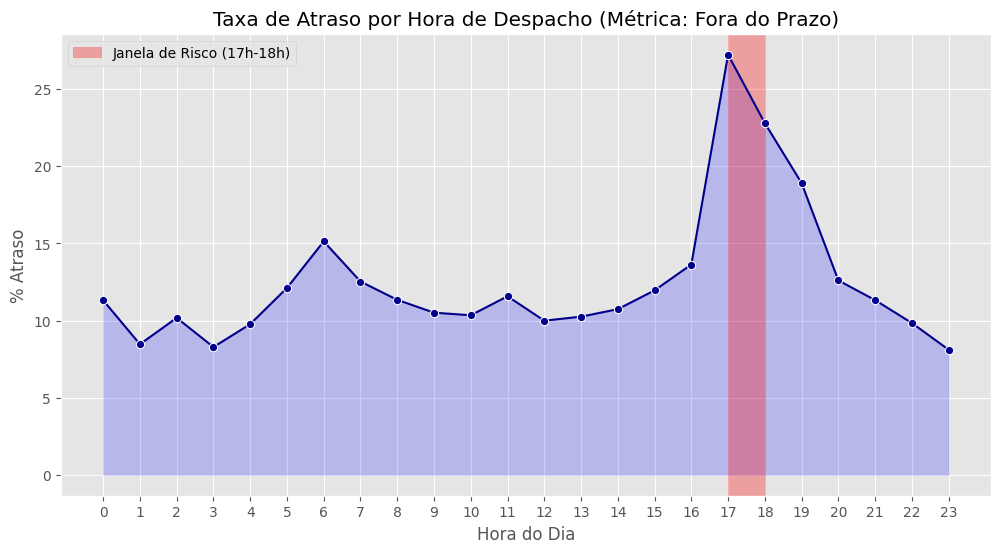

Taxa de atraso entre 17h e 18h: 27.24%


In [294]:
atraso_por_hora = df.groupby('hora_despacho')['is_atrasado'].mean() * 100

plt.figure(figsize=(12, 6))
sns.lineplot(x=atraso_por_hora.index, y=atraso_por_hora.values, marker='o', color='darkblue')
plt.fill_between(atraso_por_hora.index, atraso_por_hora.values, alpha=0.2, color='blue')
plt.axvspan(17, 18, color='red', alpha=0.3, label='Janela de Risco (17h-18h)')
plt.title('Taxa de Atraso por Hora de Despacho (Métrica: Fora do Prazo)')
plt.xlabel('Hora do Dia')
plt.ylabel('% Atraso')
plt.xticks(range(24))
plt.legend()
plt.show()

print(f"Taxa de atraso entre 17h e 18h: {atraso_por_hora.loc[17]:.2f}%")

### Análise por Transportadora

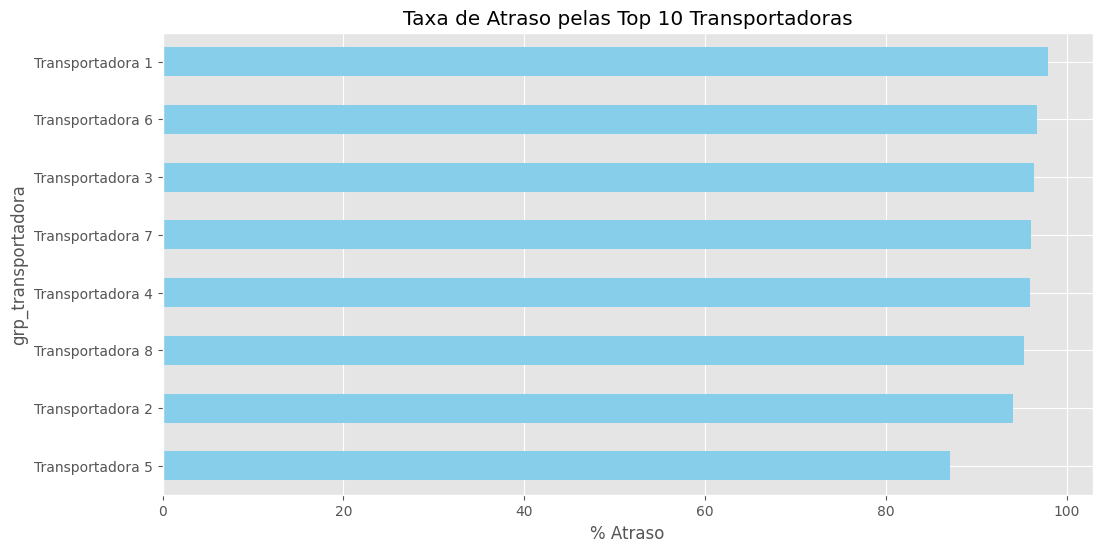

In [295]:
top_transportadoras = df['grp_transportadora'].value_counts().head(10).index
atraso_transp = df[df['grp_transportadora'].isin(top_transportadoras)].groupby('grp_transportadora')['tp_performance_entrega'].mean() * 100

plt.figure(figsize=(12, 6))
atraso_transp.sort_values().plot(kind='barh', color='skyblue')
plt.title('Taxa de Atraso pelas Top 10 Transportadoras')
plt.xlabel('% Atraso')
plt.show()

### Análise Regional (UF)

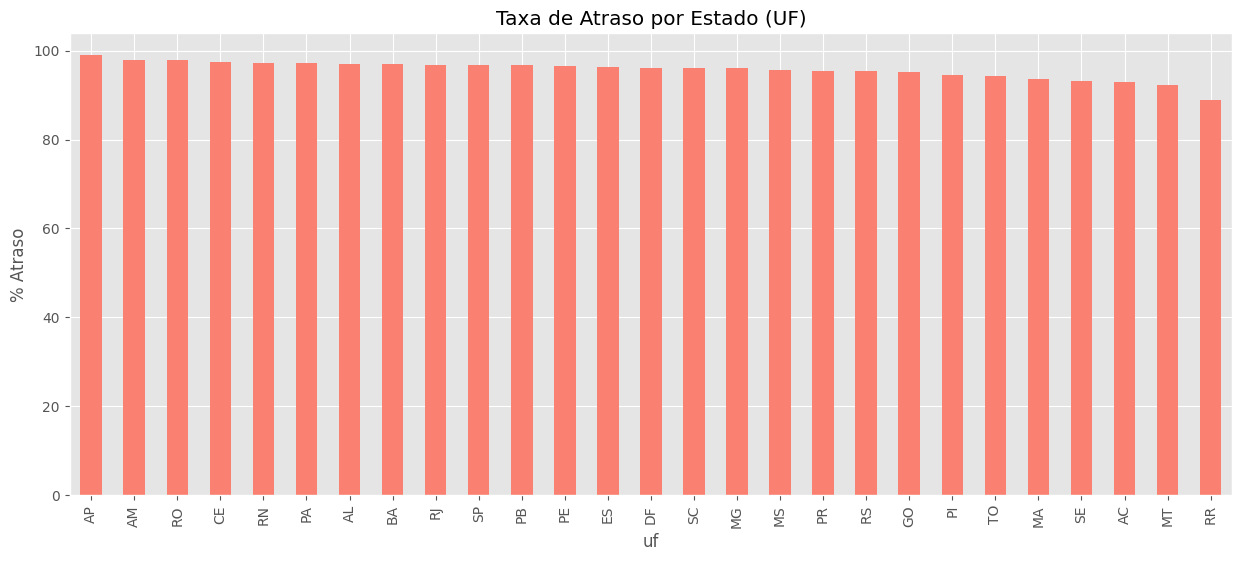

In [296]:
atraso_uf = df.groupby('uf')['tp_performance_entrega'].mean() * 100

plt.figure(figsize=(15, 6))
atraso_uf.sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Taxa de Atraso por Estado (UF)')
plt.ylabel('% Atraso')
plt.show()

### Analise por Cidade Destinatário

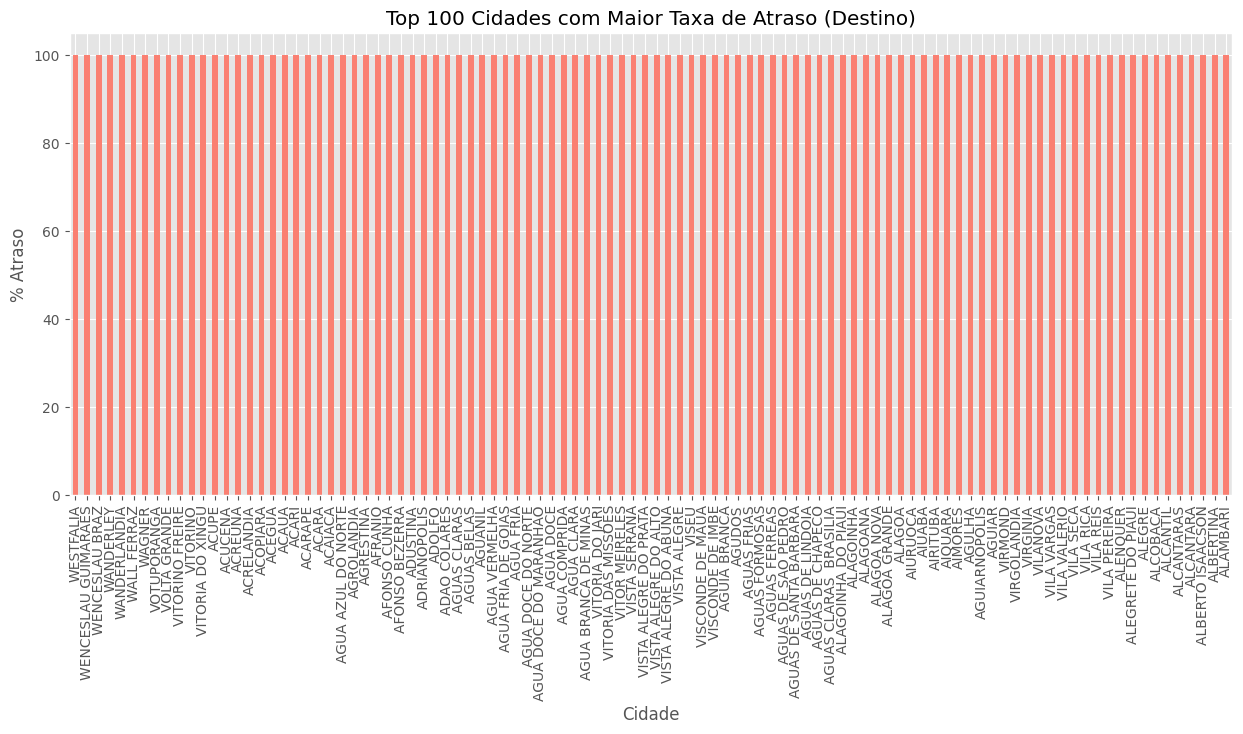

In [297]:
# 1. Calcula a taxa média e ordena do maior para o menor, pegando os 10 primeiros
atraso_top_100 = (df.groupby('cidade_destinatario')['tp_performance_entrega'].mean() * 100).sort_values(ascending=False).head(100)

# 2. Plotagem
plt.figure(figsize=(15, 6))
atraso_top_100.plot(kind='bar', color='salmon')
plt.title('Top 100 Cidades com Maior Taxa de Atraso (Destino)')
plt.ylabel('% Atraso')
plt.xlabel('Cidade')
#plt.xticks(rotation=45)
plt.show()

### Taxa de atraso por Centro de Distribuição (Origem)

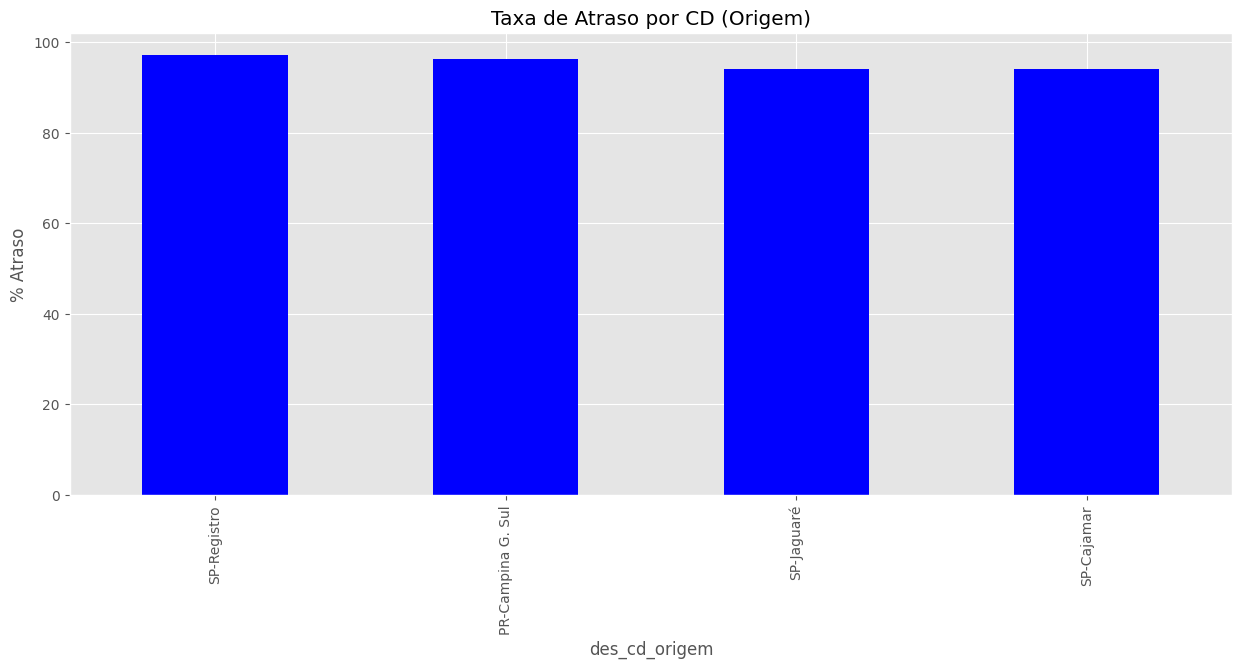

In [298]:
atraso_cd = df.groupby('des_cd_origem')['tp_performance_entrega'].mean() * 100

plt.figure(figsize=(15, 6))
atraso_cd.sort_values(ascending=False).plot(kind='bar', color='blue')
plt.title('Taxa de Atraso por CD (Origem)')
plt.ylabel('% Atraso')
plt.show()

### Tempo de Trânsito por Transportadora

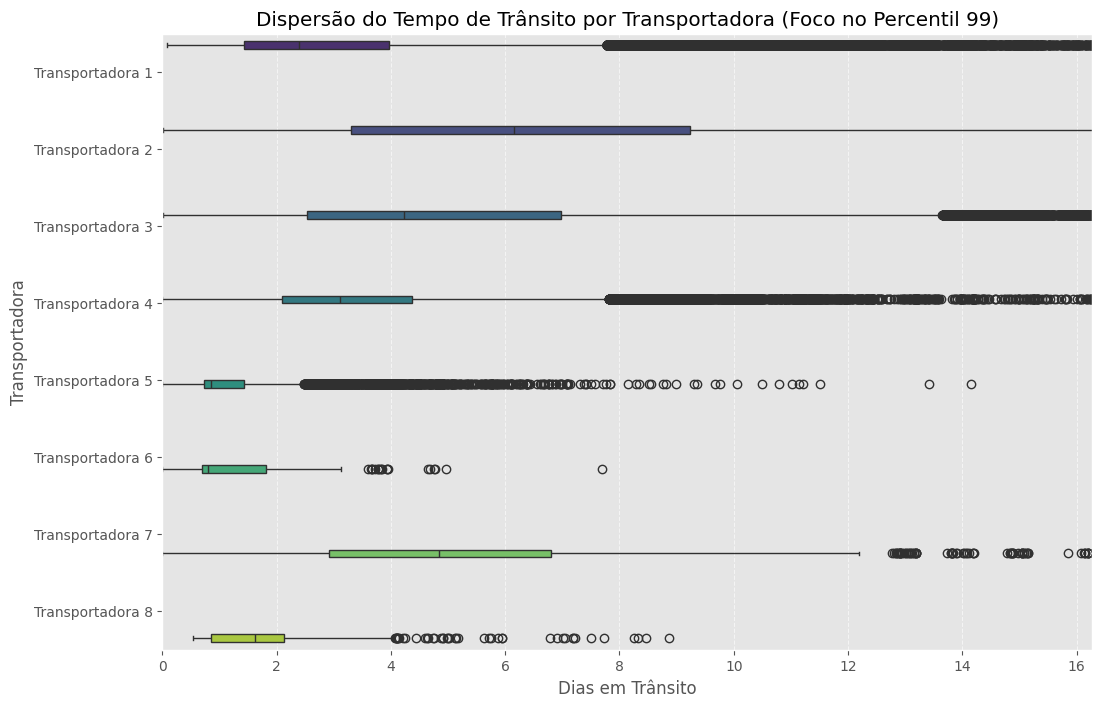

Nota: O gráfico foi limitado a 16.3 dias para melhor visualização (ignora-se <1% de casos extremos).


In [299]:
import seaborn as sns
import matplotlib.pyplot as plt
# Calculando um limite para o eixo X (99% dos dados) para evitar o visual "esmagado"
# pelos outliers mais extremos
limite_x = df['dias_transito'].quantile(0.99)
plt.figure(figsize=(12, 8))
# Criando o Boxplot corrigido
sns.boxplot(
    data=df, 
    x='dias_transito', 
    y='grp_transportadora', 
    hue='grp_transportadora',  # Define a variável de cor explicitamente
    palette='viridis', 
    legend=False               # Remove a legenda redundante
)
# Ajustando o limite do eixo X para focar onde a massa de dados está
plt.xlim(0, limite_x) 
plt.title('Dispersão do Tempo de Trânsito por Transportadora (Foco no Percentil 99)')
plt.xlabel('Dias em Trânsito')
plt.ylabel('Transportadora')
plt.grid(axis='x', linestyle='--', alpha=0.6) # Adiciona linhas de grade para facilitar leitura
plt.show()
print(f"Nota: O gráfico foi limitado a {limite_x:.1f} dias para melhor visualização (ignora-se <1% de casos extremos).")

# Por que fazer o Boxplot: O tempo de trânsito costuma ser o maior ofensor nos atrasos logísticos. 
# Uma assimetria positiva de 23.28 significa que a maioria das entregas ocorre num tempo padrão, 
# mas existem atrasos de transporte absurdos puxando a média para cima.


### Dias de Processamento CD por Mês

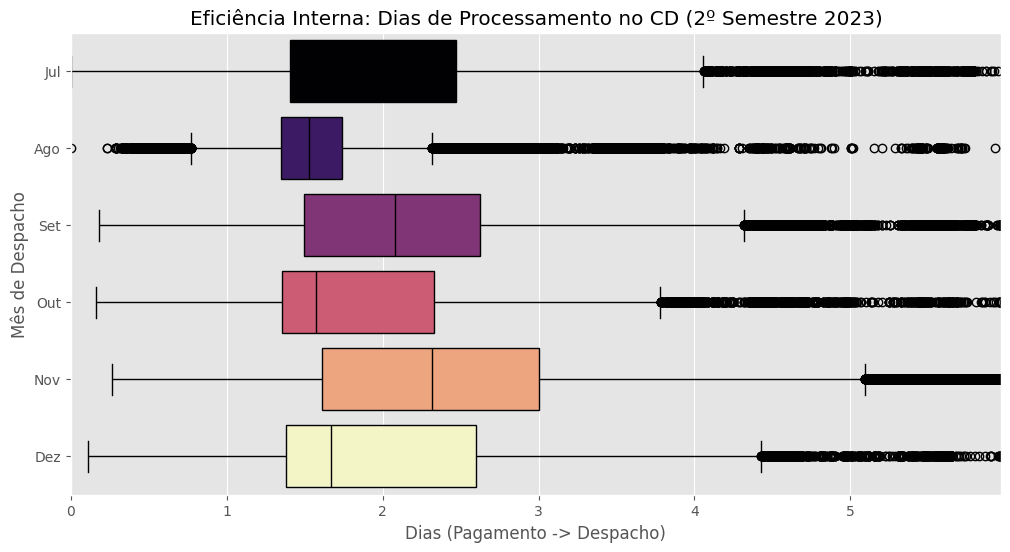

In [300]:
plt.figure(figsize=(12, 6))
# Garantindo que os meses apareçam na ordem cronológica do 2º semestre
ordem_meses = [7, 8, 9, 10, 11, 12] 
# Filtramos o DF apenas para esses meses (caso ainda não esteja filtrado globalmente)
df_2sem = df[df['mes_despacho'].isin(ordem_meses)].copy()
limite_cd = df_2sem['dias_gastos_cd'].quantile(0.99)
sns.boxplot(
    data=df_2sem, 
    x='dias_gastos_cd', 
    y='mes_despacho', 
    hue='mes_despacho', 
    order=ordem_meses, # Força a ordem correta no eixo Y
    orient='h',
    palette='magma', 
    legend=False
)
plt.xlim(0, limite_cd)
# Melhorando o rótulo do eixo Y para nomes de meses se preferir
plt.yticks(ticks=range(6), labels=['Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.title('Eficiência Interna: Dias de Processamento no CD (2º Semestre 2023)')
plt.xlabel('Dias (Pagamento -> Despacho)')
plt.ylabel('Mês de Despacho')
plt.show()

# Por que essas visualizações?
# Processamento CD: Revela se o problema de atraso nasce "dentro de casa".

# Dica de Análise: Útil para ver se existem dias específicos da semana em que os CDs não conseguem dar conta, 
# ou se tem picos de outliers em eventos sazonais (ex: Black Friday).

### Dias de Ciclo Total: No Prazo vs Atrasados

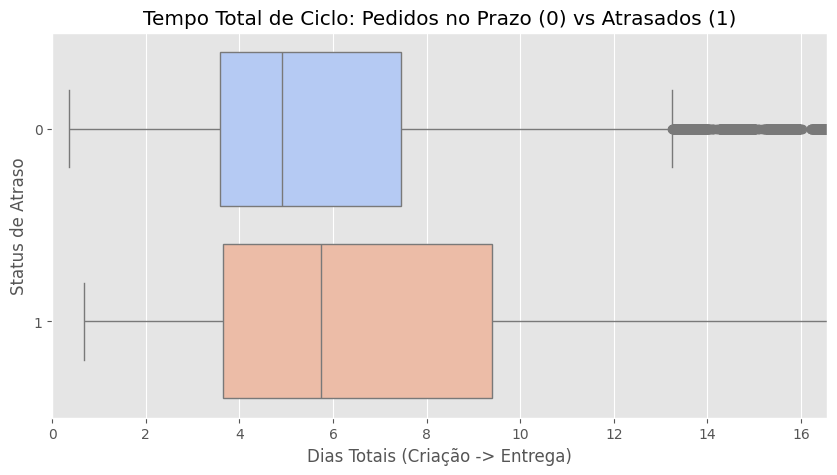

In [301]:
plt.figure(figsize=(10, 5))
limite_ciclo = df['dias_ciclo'].quantile(0.98) # 98% para focar mais na massa principal
sns.boxplot(
    data=df, 
    x='dias_ciclo', 
    y='is_atrasado', 
    hue='is_atrasado',
    orient='h',
    palette='coolwarm',
    legend=False
)
plt.xlim(0, limite_ciclo)
plt.title('Tempo Total de Ciclo: Pedidos no Prazo (0) vs Atrasados (1)')
plt.xlabel('Dias Totais (Criação -> Entrega)')
plt.ylabel('Status de Atraso')
plt.show()

# Ciclo Total: Mostra a variabilidade da experiência do cliente. Se a "caixa" do grupo atrasado 
# for muito larga, sua operação é imprevisível.

### Distribuição da Intensidade do Atraso (Histograma)

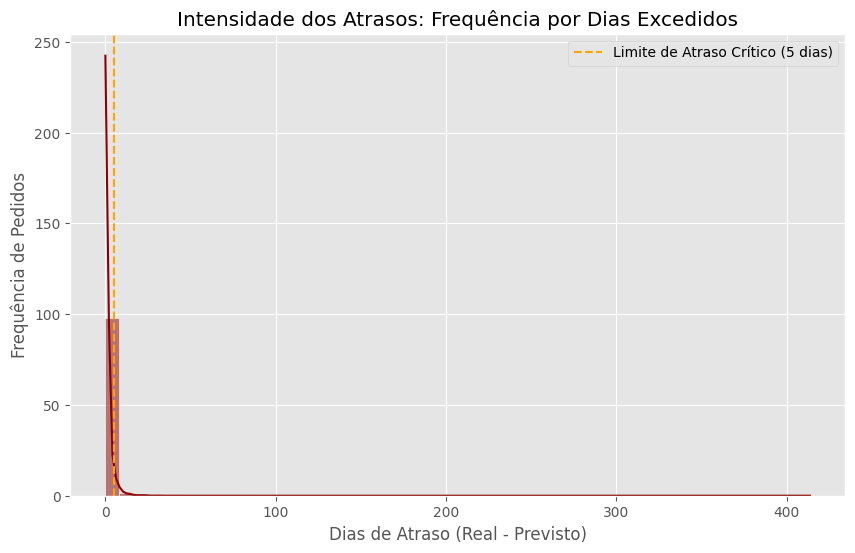

Média de dias de atraso (apenas dos atrasados): 1.54 dias


In [302]:
# 1. Histograma: Problema Operacional Leve vs. Grave
plt.figure(figsize=(10, 6))
# Filtramos apenas onde o atraso real é maior que 0
atrasos_positivos = df[df['dias_atraso_real'] > 0]['dias_atraso_real']
# print(atrasos_positivos)
# Versão ajustada com % no Eixo Y
sns.histplot(atrasos_positivos, bins=50, kde=True, color='darkred', stat='percent')
plt.ylabel('Porcentagem de Pedidos Atrasados (%)')
# Linha de corte sugestiva para atraso grave (ex: 5 dias)
plt.axvline(5, color='orange', linestyle='--', label='Limite de Atraso Crítico (5 dias)')
plt.title('Intensidade dos Atrasos: Frequência por Dias Excedidos')
plt.xlabel('Dias de Atraso (Real - Previsto)')
plt.ylabel('Frequência de Pedidos')
plt.legend()
plt.show()
print(f"Média de dias de atraso (apenas dos atrasados): {atrasos_positivos.mean():.2f} dias")

# Este gráfico foca especificamente no "tamanho da dor". Ele ignora o que foi entregue no prazo 
# e analisa apenas o quão grave são os atrasos.

### Sazonalidade Mensal (Performance 2º Semestre)

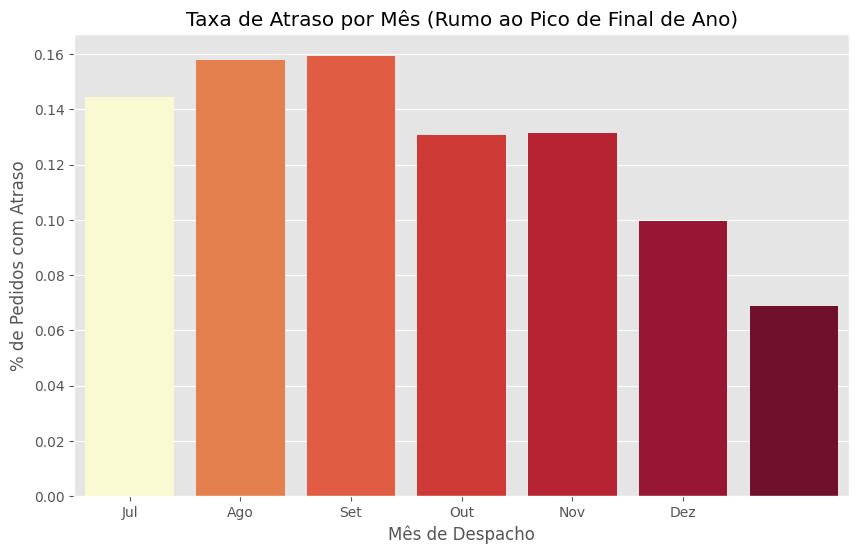

In [303]:
# Taxa de Atraso por Mês (Impacto Sazonal)
aux_mensal = df.groupby('mes_despacho')['is_atrasado'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=aux_mensal, x='mes_despacho', y='is_atrasado', palette='YlOrRd', hue='mes_despacho', legend=False)
plt.title('Taxa de Atraso por Mês (Rumo ao Pico de Final de Ano)')
plt.xlabel('Mês de Despacho')
plt.ylabel('% de Pedidos com Atraso')
plt.xticks(ticks=range(6), labels=['Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']) # Ajustado para o 2º sem
plt.show()

# Aqui comparamos a taxa de sucesso de entrega ao longo dos meses para validar 
# o impacto da Black Friday (Novembro) e Natal.

### Boxplot de Lead Time por Região (UF)

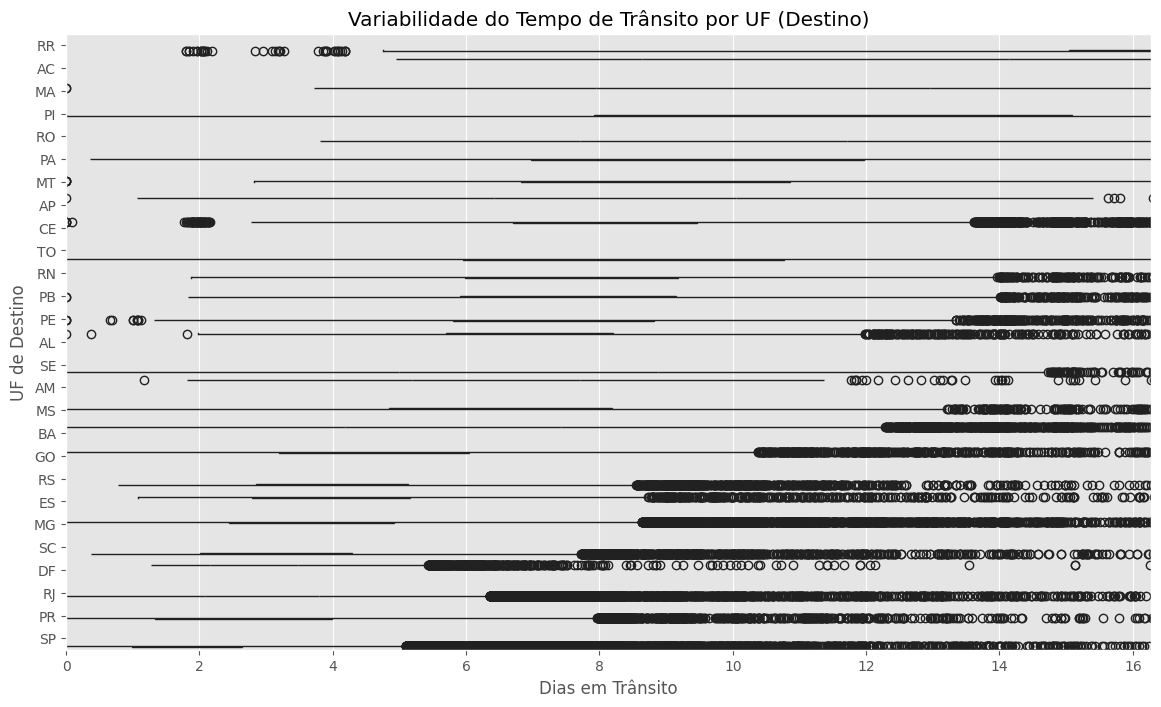

In [304]:
# Variabilidade do Lead Time (Dias de Trânsito) por Estado
plt.figure(figsize=(14, 8))
# Ordenando os estados pela mediana de dias de trânsito
order_uf = df.groupby('uf')['dias_transito'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df, 
    x='dias_transito', 
    y='uf', 
    order=order_uf, 
    hue='uf',
    palette='viridis',
    legend=False
)
plt.xlim(0, df['dias_transito'].quantile(0.99)) # Limite no 99% para visibilidade
plt.title('Variabilidade do Tempo de Trânsito por UF (Destino)')
plt.xlabel('Dias em Trânsito')
plt.ylabel('UF de Destino')
plt.show()

# Este é fundamental para identificar se a variabilidade (o "bigode" do gráfico) é maior em estados distantes 
# (como Norte e Nordeste), o que indicaria problemas de rota.

### O "Termômetro": Caso Prático com dias_atraso_real

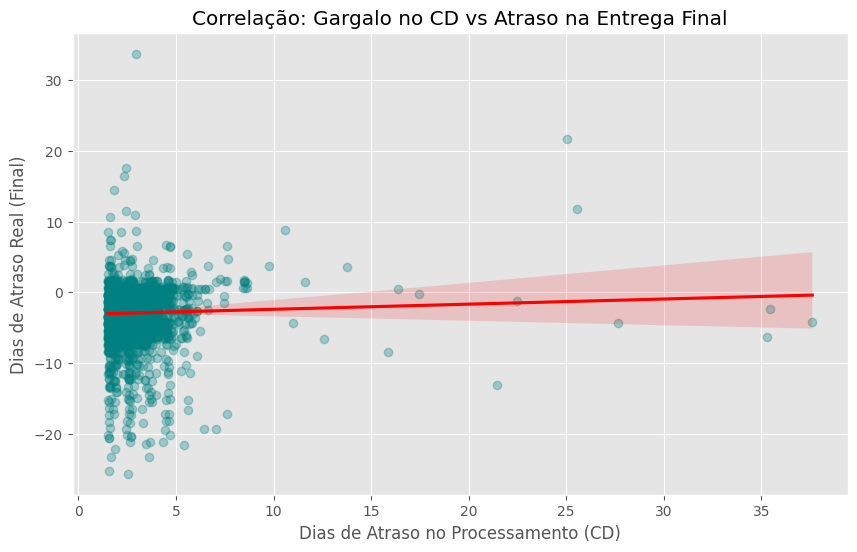

Correlação entre atraso no CD e atraso final: 0.03


In [305]:
# Caso Prático: O Atraso no CD empurra o Atraso Final?
plt.figure(figsize=(10, 6))
# Amostra para facilitar a visualização (apenas os que tiveram algum atraso no CD)
df_atraso_cd = df[df['dias_gastos_cd'] > 1.5].sample(min(3000, len(df)))
sns.regplot(
    data=df_atraso_cd, 
    x='dias_gastos_cd', 
    y='dias_atraso_real', 
    scatter_kws={'alpha':0.3, 'color':'teal'}, 
    line_kws={'color':'red'}
)
plt.title('Correlação: Gargalo no CD vs Atraso na Entrega Final')
plt.xlabel('Dias de Atraso no Processamento (CD)')
plt.ylabel('Dias de Atraso Real (Final)')
plt.show()
correlacao = df_atraso_cd[['dias_gastos_cd', 'dias_atraso_real']].corr().iloc[0,1]
print(f"Correlação entre atraso no CD e atraso final: {correlacao:.2f}")

Insight de Negócio: Encontramos uma correlação fraca (próximo 0.1) entre o tempo de processamento interno e o atraso real. Isso indica que a eficiência do Centro de Distribuição, embora importante, não é o fator determinante para o cliente receber o produto fora do prazo. O foco de melhoria deve ser deslocado para o desempenho das transportadoras e análise de rotas (UFs). (by Gemini 3 Flash / Antigravity)